In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score, confusion_matrix
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.lines as mlines
import seaborn as sns
import re
import os
import warnings


warnings.filterwarnings("ignore")
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
sns.set_theme(style="whitegrid", context="poster", font_scale=1.5)

def save_multiformat(base_filename, directory="../figures"):
    os.makedirs(directory, exist_ok=True)
    plt.savefig(f"{directory}/{base_filename}.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{directory}/{base_filename}.pdf", format='pdf', bbox_inches='tight')

In [2]:
# ==========================================
# 0. IMPORTS
# ==========================================
import re
import warnings

import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
from scipy.special import expit
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"

MCMC_FILES = {
    '2. Multidim Latent LMM': "/nobackup/zwu1/gnpc_explor/new_results/results_S1_mltlmm_run1.csv",
    '3. Diag OU': "../new_results/results_S1_dahlou_ncp_full_diag_run1.csv",
    '4. CLOUD': "../new_results/results_S1_dahlou_ncp_full_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}

all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations
df['Total Score'] = df[all_items].sum(axis=1)

for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta']).reset_index(drop=True)
df['_row_id'] = np.arange(len(df))

df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time interactions for dynamic covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

MODEL2_NAME = '2. Multidim Latent LMM'


# ==========================================
# SAFE EXTRACTION HELPERS
# ==========================================
def get_z(m, term):
    try:
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def get_se(m, term):
    try:
        v = m.bse[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def get_est(m, term):
    try:
        v = m.params[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def add_metrics(model_name, level, target, actual, expected):
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)

    mask = ~np.isnan(expected) & ~np.isnan(actual)

    if not np.any(mask):
        return

    actual_m, expected_m = actual[mask], expected[mask]

    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)

    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        try:
            kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
        except Exception:
            kappa = np.nan
    else:
        exact, kappa = np.nan, np.nan

    metrics_results.append({
        'Model': model_name,
        'Level': level,
        'Target': target,
        'RMSE': rmse,
        'MAE': mae,
        'Exact_Match_%': exact,
        'Weighted_Kappa': kappa
    })


# ==========================================
# 1. BASELINES: FIT & PREDICT (LMM Only)
# ==========================================
print("\nFitting Standard Baseline Models...")

# ==========================================================
# 1A. ITEM-LEVEL MODELS
# ==========================================================
for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1)

    req_cols = (
        [item, 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta']
        + meas_covariates
        + [f"{c}_x_Time" for c in dyn_covariates]
        + [f"{c}_x_Gap" for c in dyn_covariates]
    )

    df_clean = df.dropna(subset=req_cols).copy()

    if df_clean.empty:
        continue

    # --- Model 1: LMM ---
    m1 = None
    try:
        m1 = smf.mixedlm(
            f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}",
            data=df_clean,
            groups=df_clean["subject_id"]
        ).fit(reml=False, disp=False)
    except Exception:
        try:
            m1 = smf.ols(
                f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}",
                data=df_clean
            ).fit()
        except Exception:
            pass

    if m1 is not None:
        add_metrics(
            '1. LMM',
            'Item',
            item,
            df_clean[item].values,
            np.clip(np.asarray(m1.fittedvalues, dtype=float), 0, 4)
        )

        for c in meas_covariates:
            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': '1. LMM',
                'Z_Score': get_z(m1, c),
                'SE': get_se(m1, c),
                'Est': get_est(m1, c)
            })

        for c in dyn_covariates:
            covariate_results.append({
                'Item': item,
                'Covariate': c,
                'Model': '1. LMM',
                'Z_Score': get_z(m1, f'{c}_x_Time'),
                'SE': get_se(m1, f'{c}_x_Time'),
                'Est': get_est(m1, f'{c}_x_Time')
            })


# ==========================================================
# 1B. MACRO-LEVEL MODELS: TOTAL SCORE AND DOMAINS
# ==========================================================
for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12

    df_agg = df.dropna(
        subset=(
            [target, 'ALSFRS_Delta']
            + meas_covariates
            + [f"{c}_x_Time" for c in dyn_covariates]
        )
    ).copy()

    if df_agg.empty:
        continue

    agg_form_1 = (
        f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
        if ' ' in target
        else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    )

    # --- Model 1: LMM Macro ---
    agg1 = None
    try:
        agg1 = smf.mixedlm(
            agg_form_1,
            data=df_agg,
            groups=df_agg["subject_id"]
        ).fit(reml=False, disp=False)
    except Exception:
        try:
            agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception:
            pass

    if agg1 is not None:
        add_metrics(
            '1. LMM',
            level,
            target,
            df_agg[target].values,
            np.clip(np.asarray(agg1.fittedvalues, dtype=float), 0, max_val)
        )


# ==========================================
# 2. EXTRACT MCMC METRICS & COVARIATES (STAN)
# ==========================================
print("\nExtracting Stan MCMC Parameters across restricted domains...")

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["

    subset = df_m[df_m['Parameter'].astype(str).str.contains(pattern, regex=True)].copy()

    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', str(r['Parameter']))
            if not idx_str:
                continue
            idx = [int(i) - 1 for i in idx_str.group(1).split(',')]

            if len(idx) > len(shape):
                continue

            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0:
                    valid = False
            if not valid:
                continue

            if len(idx) == 1:
                out[idx[0]] = r['Estimate']
            elif len(idx) == 2:
                out[idx[0], idx[1]] = r['Estimate']
            elif len(idx) == 3:
                out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

def extract_ppp(df_m, pattern, name_mapping=None):
    subset = df_m[df_m['Parameter'].astype(str).str.contains(
        pattern, regex=True, case=False
    )].copy()

    res = {}
    for _, row in subset.iterrows():
        param = str(row['Parameter'])
        est = row['Estimate']
        idx_match = re.search(r'\[(\d+)\]', param)

        if idx_match and name_mapping:
            idx = int(idx_match.group(1)) - 1
            if idx in name_mapping:
                res[name_mapping[idx]] = est
        else:
            res[param] = est
    return res

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values

sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values

domain_idx_full = {
    0: [0, 1, 2],
    1: [3, 4, 5],
    2: [6, 7, 8],
    3: [9, 10, 11]
}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")

    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12

    domain_idx = {
        0: [0, 1, 2],
        1: [3, 4, 5],
        2: [6, 7, 8]
    } if is_3d else domain_idx_full
    
    exp_sc = np.full((len(df), 12), np.nan)

    if model_name == '2. Multidim Latent LMM':
        # Mapped to mltlmm.stan parameter names
        thresh = ext_stan(df_mcmc, 'c', (12, 4))
        lat_theta = ext_stan(df_mcmc, 'theta', (len(df), 4))
        lam = ext_stan(df_mcmc, 'lambda', (12,))
        beta = ext_stan(df_mcmc, 'beta_meas', (12, 3))

        for i in range(len(df)):
            for d, items in domain_idx.items():
                for k in items:
                    # In mltlmm.stan, latent subject effects are already folded into theta[i, d]
                    eta = np.dot(X_m[i, :], beta[k]) + lam[k] * lat_theta[i, d]
                    p = [expit(1.0 * (eta - th)) for th in thresh[k]]

                    p4 = p[3]
                    p3 = p[2] - p[3]
                    p2 = p[1] - p[2]
                    p1 = p[0] - p[1]
                    p0 = 1.0 - p[0]
                    exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)
    else:
        # Standard CLOUD / Diag OU extraction
        theta = ext_stan(df_mcmc, 'theta', (12, 4))
        lam = ext_stan(df_mcmc, 'lambda', (12,))
        beta = ext_stan(df_mcmc, 'beta', (12, 3))
        xi = ext_stan(df_mcmc, 'xi', (4, len(df)))
        b = ext_stan(df_mcmc, 'b', (len(sub_map), 12))

        for i in range(len(df)):
            for d, items in domain_idx.items():
                for k in items:
                    eta = np.dot(X_m[i, :], beta[k]) + lam[k] * xi[d, i] + b[ID[i], k]
                    p = [expit(1.0 * (eta - th)) for th in theta[k]]

                    p4 = p[3]
                    p3 = p[2] - p[3]
                    p2 = p[1] - p[2]
                    p1 = p[0] - p[1]
                    p0 = 1.0 - p[0]
                    exp_sc[i, k] = (0 * p0) + (1 * p1) + (2 * p2) + (3 * p3) + (4 * p4)

    # Track metrics
    for k in range(valid_k):
        add_metrics(
            model_name,
            'Item',
            all_items[k],
            actual_sc[:, k],
            exp_sc[:, k]
        )

    for d, items_ in domain_idx.items():
        add_metrics(
            model_name,
            'Domain',
            list(domains.keys())[d],
            actual_sc[:, items_].sum(axis=1),
            exp_sc[:, items_].sum(axis=1)
        )

    if not is_3d:
        add_metrics(
            model_name,
            'Overall',
            'Total Score',
            actual_sc.sum(axis=1),
            exp_sc.sum(axis=1)
        )

    # Covariate Extractions
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    # Support 'beta' for CLOUD and 'beta_meas' for mltlmm
    df_beta = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^beta(?:_meas)?\[', regex=True
    )].copy()

    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta:
                continue

            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k:
                continue

            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

            covariate_results.append({
                'Item': item_name,
                'Covariate': c_name,
                'Model': model_name,
                'Z_Score': est / se if se != 0 else 0.0,
                'SE': se,
                'Est': est
            })

    # Both CLOUD and mltlmm utilize alpha_dyn for continuous latent covariates
    df_alpha = df_mcmc[df_mcmc['Parameter'].astype(str).str.contains(
        r'^alpha_dyn\[', regex=True
    )].copy()

    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].astype(str).str.extract(
            r'\[(\d+),(\d+)\]'
        ).astype(int)

        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha:
                continue

            dom_idx = int(row['Dim1']) - 1
            if dom_idx not in domain_idx:
                continue

            c_name = cov_map_alpha[c_idx]
            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)

            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]

                comp_est = lam_k * phi_est
                comp_se = abs(lam_k) * phi_se

                covariate_results.append({
                    'Item': item_name,
                    'Covariate': c_name,
                    'Model': model_name,
                    'Z_Score': comp_est / comp_se if comp_se != 0 else 0.0,
                    'SE': comp_se,
                    'Est': comp_est
                })


# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")

mod_order = [
    '1. LMM',
    MODEL2_NAME,
    '3. Diag OU',
    '4. CLOUD',
]

# Metrics
df_metrics = pd.DataFrame(metrics_results)

if df_metrics.empty:
    df_metrics = pd.DataFrame(columns=[
        'Model', 'Level', 'Target', 'RMSE', 'MAE', 'Exact_Match_%', 'Weighted_Kappa'
    ])
else:
    df_metrics = df_metrics.dropna(subset=['RMSE'])

df_metrics['Level'] = pd.Categorical(
    df_metrics['Level'],
    categories=['Overall', 'Domain', 'Item'],
    ordered=True
)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

# Covariates
df_covs = pd.DataFrame(covariate_results)
if df_covs.empty:
    df_covs = pd.DataFrame(columns=[
        'Item', 'Covariate', 'Model', 'Z_Score', 'SE', 'Est'
    ])

df_covs['Item'] = pd.Categorical(
    df_covs['Item'],
    categories=list(reversed(all_items)),
    ordered=True
)
df_covs['Model'] = pd.Categorical(
    df_covs['Model'],
    categories=mod_order,
    ordered=True
)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

target_order = [
    'Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory'
]

df_macro['Target'] = pd.Categorical(
    df_macro['Target'],
    categories=target_order,
    ordered=True
)

df_item = df_metrics[df_metrics['Level'] == 'Item'].copy()

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("=" * 105)

piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(
    piv_macro_rmse
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("=" * 105)

piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(
    piv_macro_mae
    .reindex(index=target_order, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

print("\n" + "=" * 105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("=" * 105)

piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')

print("--- ITEM EXACT MATCH % ---")
print(
    piv_item_exact
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.1f}".format, na_rep="-")
)

print("\n--- ITEM WEIGHTED KAPPA ---")
print(
    piv_item_kappa
    .reindex(index=all_items, columns=mod_order)
    .to_string(float_format="{:.3f}".format, na_rep="-")
)

# ==========================================
# 6. GAMMA & PHI MATRIX EXTRACTION
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: CLOUD MODEL LATENT MATRICES (GAMMA & PHI)")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']

    def extract_matrix_summary(df_m, param_name):
        pattern = rf"^{param_name}\["
        subset = df_m[df_m['Parameter'].astype(str).str.contains(
            pattern, case=False, regex=True
        )].copy()

        if subset.empty:
            return None

        try:
            subset[['Dim1', 'Dim2']] = subset['Parameter'].astype(str).str.extract(
                r'\[(\d+),(\d+)\]'
            ).astype(int)
        except Exception:
            return None

        if 'sd' in subset.columns:
            subset['Std'] = subset['sd']
        elif 'StdDev' in subset.columns:
            subset['Std'] = subset['StdDev']
        elif '97.5%' in subset.columns and '2.5%' in subset.columns:
            subset['Std'] = (subset['97.5%'] - subset['2.5%']) / (2 * 1.96)
        else:
            subset['Std'] = 0.0

        subset['Formatted'] = subset.apply(
            lambda r: f"{r['Estimate']:.3f} ({r['Std']:.3f})",
            axis=1
        )
        return subset.pivot(index='Dim1', columns='Dim2', values='Formatted')

    gamma_mat = extract_matrix_summary(df_cloud, 'gamma')
    phi_mat = extract_matrix_summary(df_cloud, 'phi')

    if phi_mat is None:
        phi_mat = extract_matrix_summary(df_cloud, 'alpha_dyn')

    print("--- GAMMA (Latent Drift Matrix) : Mean (Std) ---")
    if gamma_mat is not None:
        print(gamma_mat.to_string(na_rep="-"))
    else:
        print("No Gamma matrix parameters found in MCMC output.")

    print("\n--- PHI (Latent Covariate Parameter Matrix) : Mean (Std) ---")
    if phi_mat is not None:
        print(phi_mat.to_string(na_rep="-"))
    else:
        print("No Phi/alpha_dyn matrix parameters found in MCMC output.")
else:
    print("CLOUD model results not available for matrix extraction.")

# ==========================================
# 7. POSTERIOR PREDICTIVE P-VALUES
# ==========================================
print("\n" + "=" * 105)
print("TERMINAL EXPORT: POSTERIOR PREDICTIVE P-VALUES (PPP) FOR CLOUD")
print("=" * 105)

if '4. CLOUD' in mcmc_dfs and not mcmc_dfs['4. CLOUD'].empty:
    df_cloud = mcmc_dfs['4. CLOUD']
    item_map = {i: all_items[i] for i in range(len(all_items))}
    domain_map = {i: list(domains.keys())[i] for i in range(len(domains))}

    item_ppp = extract_ppp(df_cloud, r'^ppp_item\[', name_mapping=item_map)
    domain_ppp = extract_ppp(df_cloud, r'^ppp_domain\[', name_mapping=domain_map)

    total_ppp_df = df_cloud[df_cloud['Parameter'].astype(str).str.contains(
        r'^ppp_total', regex=True, case=False
    )]
    total_ppp = total_ppp_df['Estimate'].values[0] if not total_ppp_df.empty else None

    print(
        f"{'--- ITEM-LEVEL PPP ---':<35} | "
        f"{'--- DOMAIN-LEVEL PPP ---':<35} | "
        f"--- TOTAL SCORE PPP ---"
    )

    max_len = max(len(item_ppp), len(domain_ppp), 1)
    item_list = list(item_ppp.items()) if item_ppp else []
    dom_list = list(domain_ppp.items()) if domain_ppp else []

    if not item_list and not dom_list and total_ppp is None:
        print("No PPP parameters such as 'ppp_item', 'ppp_domain', or 'ppp_total' found in the MCMC output.")
    else:
        for i in range(max_len):
            i_str = f"{item_list[i][0]}: {item_list[i][1]:.3f}" if i < len(item_list) else ""
            d_str = f"{dom_list[i][0]}: {dom_list[i][1]:.3f}" if i < len(dom_list) else ""
            t_str = f"Total Score: {total_ppp:.3f}" if i == 0 and total_ppp is not None else ""
            print(f"{i_str:<35} | {d_str:<35} | {t_str}")
else:
    print("CLOUD model results not available for PPP extraction.")

print("\n=== PIPELINE 100% COMPLETE ===")

=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Fitting Standard Baseline Models...

Extracting Stan MCMC Parameters across restricted domains...
 -> Processing 2. Multidim Latent LMM...
 -> Processing 3. Diag OU...
 -> Processing 4. CLOUD...

Aggregating Results...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. LMM  2. Multidim Latent LMM  3. Diag OU  4. CLOUD
Target                                                           
Total Score   2.552                   2.338       1.546     1.533
Bulbar        0.841                   0.813       0.711     0.764
Fine_Motor    0.982                   0.980       0.522     0.527
Gross_Motor   0.971                   1.332       0.924     0.972
Respiratory   0.988                   0.760       0.483     0.500

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
Model        1. LMM  2. Multidim Latent LMM  3. Diag OU  4. CLOUD
Target                                                      

Generating Final Publication Visuals in PNG, SVG, and PDF formats...
 -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.


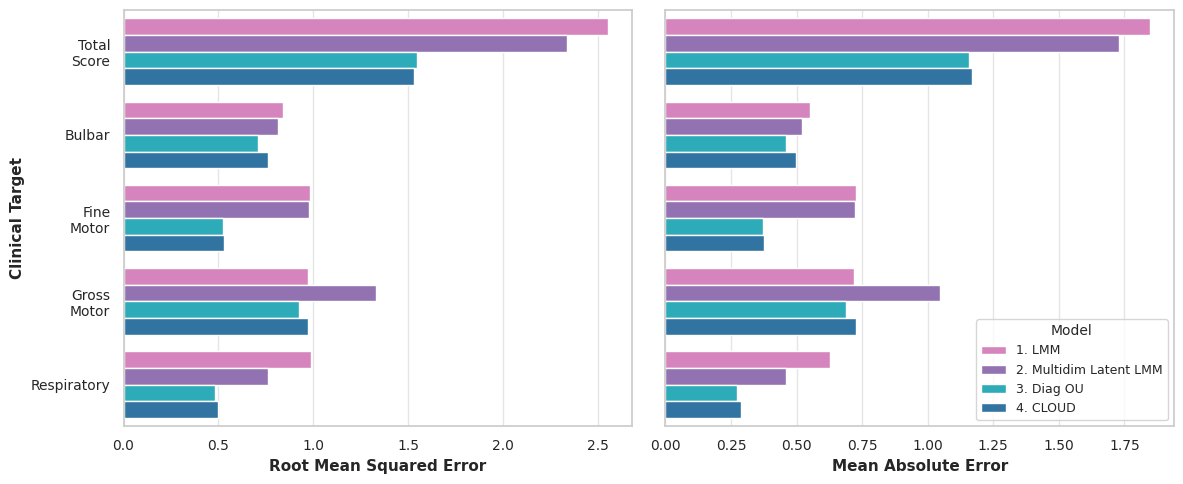

In [3]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

import matplotlib.pyplot as plt
import seaborn as sns

# Optional fallback in case save_multiformat is not already defined elsewhere
if 'save_multiformat' not in globals():
    def save_multiformat(filename, dpi=600):
        plt.savefig(f"{filename}.png", dpi=dpi, bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.svg", bbox_inches='tight', facecolor='white')
        plt.savefig(f"{filename}.pdf", bbox_inches='tight', facecolor='white')

# Ensure the multidimensional latent baseline name exists
if 'MODEL2_NAME' not in globals():
    MODEL2_NAME = '2. Multidim Latent LMM'

# White background with grid lines
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white"
    }
)

# Updated color map for the modified pipeline
model_colors = {
    '1. LMM': '#e377c2',
    MODEL2_NAME: '#9467bd',
    '3. Diag OU': '#17becf',
    '4. CLOUD': '#1f77b4',
}

# Build macro-level dataframe
df_macro_plot = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()

if df_macro_plot.empty:
    print(" -> No macro-level rows found in df_metrics. Skipping Fig_AB_Macro_Metrics.")
else:
    # Rename targets to use line breaks for tighter left margins
    rename_map = {
        'Total Score': 'Total\nScore',
        'Fine_Motor': 'Fine\nMotor',
        'Gross_Motor': 'Gross\nMotor',
        'Bulbar': 'Bulbar',
        'Respiratory': 'Respiratory'
    }

    df_macro_plot['Target_Label'] = df_macro_plot['Target'].astype(str).replace(rename_map)

    target_order = [
        'Total\nScore',
        'Bulbar',
        'Fine\nMotor',
        'Gross\nMotor',
        'Respiratory'
    ]

    df_macro_plot['Target_Label'] = pd.Categorical(
        df_macro_plot['Target_Label'],
        categories=target_order,
        ordered=True
    )

    # Use the pipeline model order when available, but only keep models that exist in df_macro_plot
    if 'mod_order' in globals():
        base_model_order = list(mod_order)
    else:
        base_model_order = [
            '1. LMM',
            MODEL2_NAME,
            '3. Diag OU',
            '4. CLOUD'
        ]

    observed_models = [
        m for m in df_macro_plot['Model'].astype(str).dropna().unique()
        if m != 'nan'
    ]

    present_model_order = [
        m for m in base_model_order
        if m in observed_models
    ]

    # Append any unexpected models that are present but not listed in mod_order
    present_model_order += [
        m for m in observed_models
        if m not in present_model_order
    ]

    # Restrict plot to models that are actually present
    df_macro_plot = df_macro_plot[
        df_macro_plot['Model'].astype(str).isin(present_model_order)
    ].copy()

    df_macro_plot['Model_Label'] = pd.Categorical(
        df_macro_plot['Model'].astype(str),
        categories=present_model_order,
        ordered=True
    )

    # Palette restricted to models present in the figure
    plot_palette = {
        m: model_colors.get(m, '#333333')
        for m in present_model_order
    }

    # Set base font sizes for publication scaling
    plt.rc('axes', titlesize=13, labelsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=9, title_fontsize=10)

    # Create a 1x2 grid sharing the Y-axis
    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 5),
        sharey=True
    )

    # ==========================================
    # Panel A: Macro-Level RMSE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='RMSE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[0]
    )

    # axes[0].set_title('Macro-Level RMSE', fontweight='bold')
    axes[0].set_xlabel('Root Mean Squared Error', fontweight='bold')
    axes[0].set_ylabel('Clinical Target', fontweight='bold')

    axes[0].grid(axis='x', linestyle='-', alpha=0.5)
    axes[0].set_axisbelow(True)

    legend0 = axes[0].get_legend()
    if legend0 is not None:
        legend0.remove()

    # ==========================================
    # Panel B: Macro-Level MAE
    # ==========================================
    sns.barplot(
        data=df_macro_plot,
        y='Target_Label',
        x='MAE',
        hue='Model_Label',
        palette=plot_palette,
        hue_order=present_model_order,
        ax=axes[1]
    )

    # axes[1].set_title('Macro-Level MAE', fontweight='bold')
    axes[1].set_xlabel('Mean Absolute Error', fontweight='bold')
    axes[1].set_ylabel('')

    axes[1].grid(axis='x', linestyle='-', alpha=0.5)
    axes[1].set_axisbelow(True)

    axes[1].legend(
        title='Model',
        loc='lower right',
        frameon=True
    )

    plt.tight_layout()
    save_multiformat('Fig_AB_Macro_Metrics')

    print(" -> Generated manuscript-ready 'Fig_AB_Macro_Metrics' with combined panels.")

# Optional reset
# plt.rcdefaults()
# sns.reset_defaults()

 -> Extracted 12 direct beta_t_dyn domain effects for 2. Multidim Latent LMM.
 -> Extracted 12 direct alpha_dyn domain effects for 3. Diag OU.
 -> Extracted 12 direct alpha_dyn domain effects for 4. CLOUD.
 -> Saved direct domain-level forest plotting table:
    domain_level_covariate_effects_for_forest.csv
 -> No direct domain-level covariate rows found for Sex_Female. Skipping forest plot.
 -> No direct domain-level covariate rows found for Treatment_Active. Skipping forest plot.
 -> No direct domain-level covariate rows found for Age_Base. Skipping forest plot.
 -> Generated domain-level forest plot for Bulbar_Onset.
 -> Generated domain-level forest plot for FVC_Base.
 -> Generated domain-level forest plot for BMI_Base.


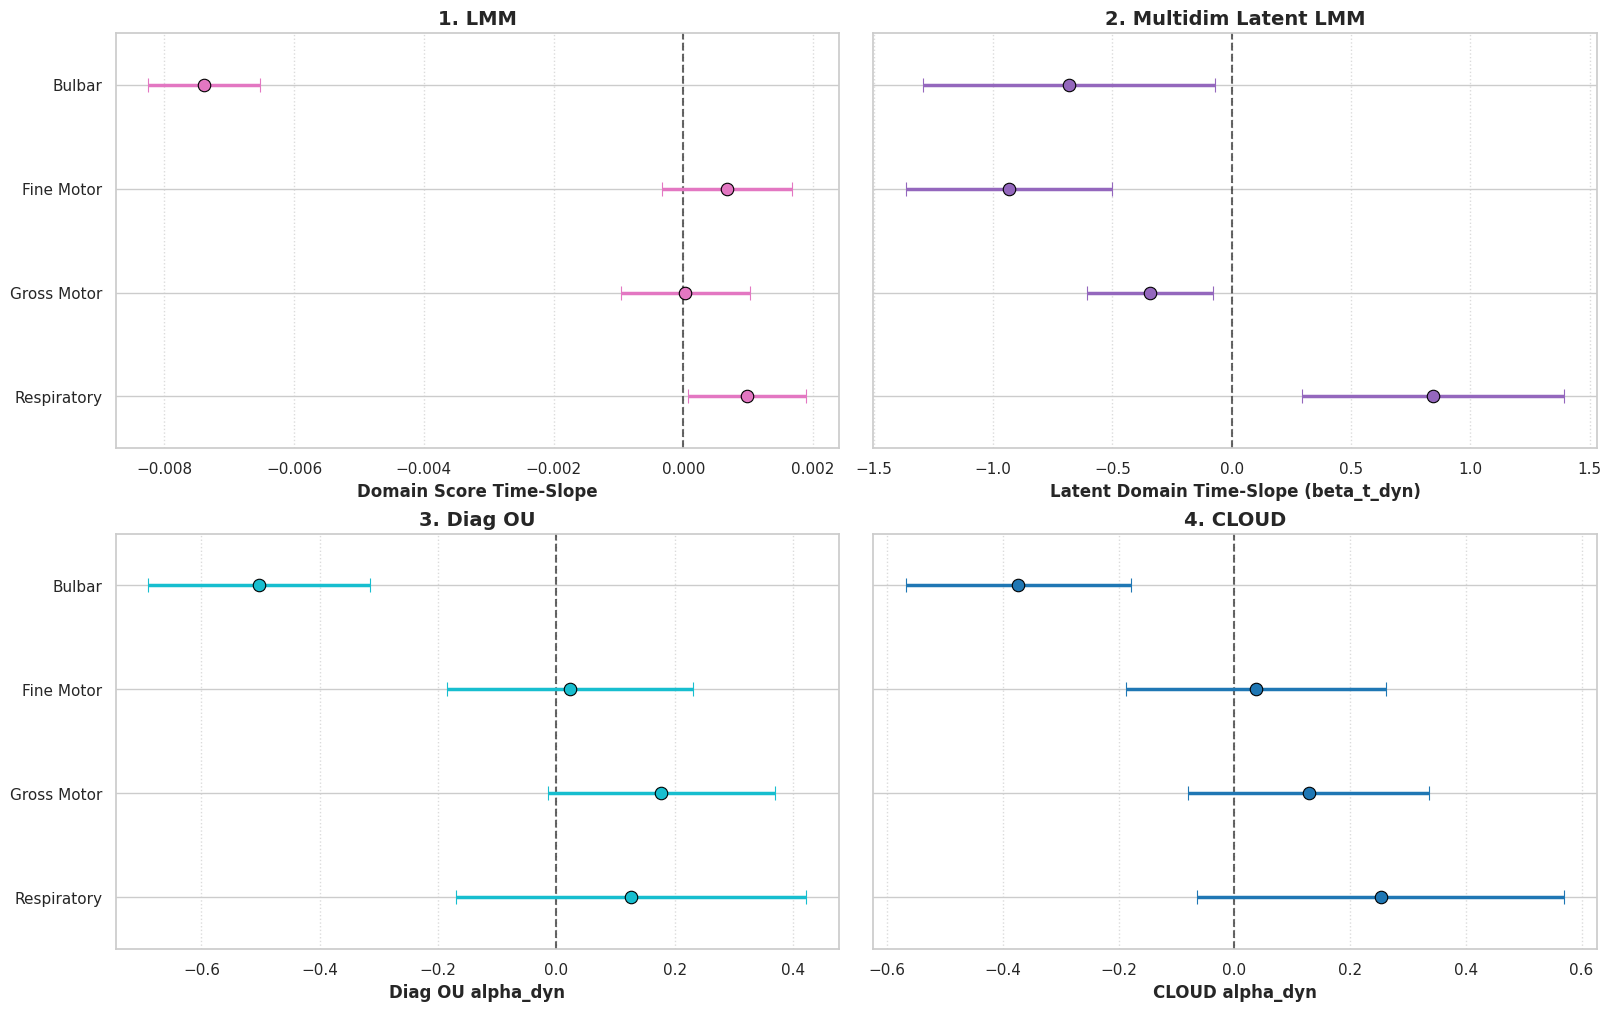

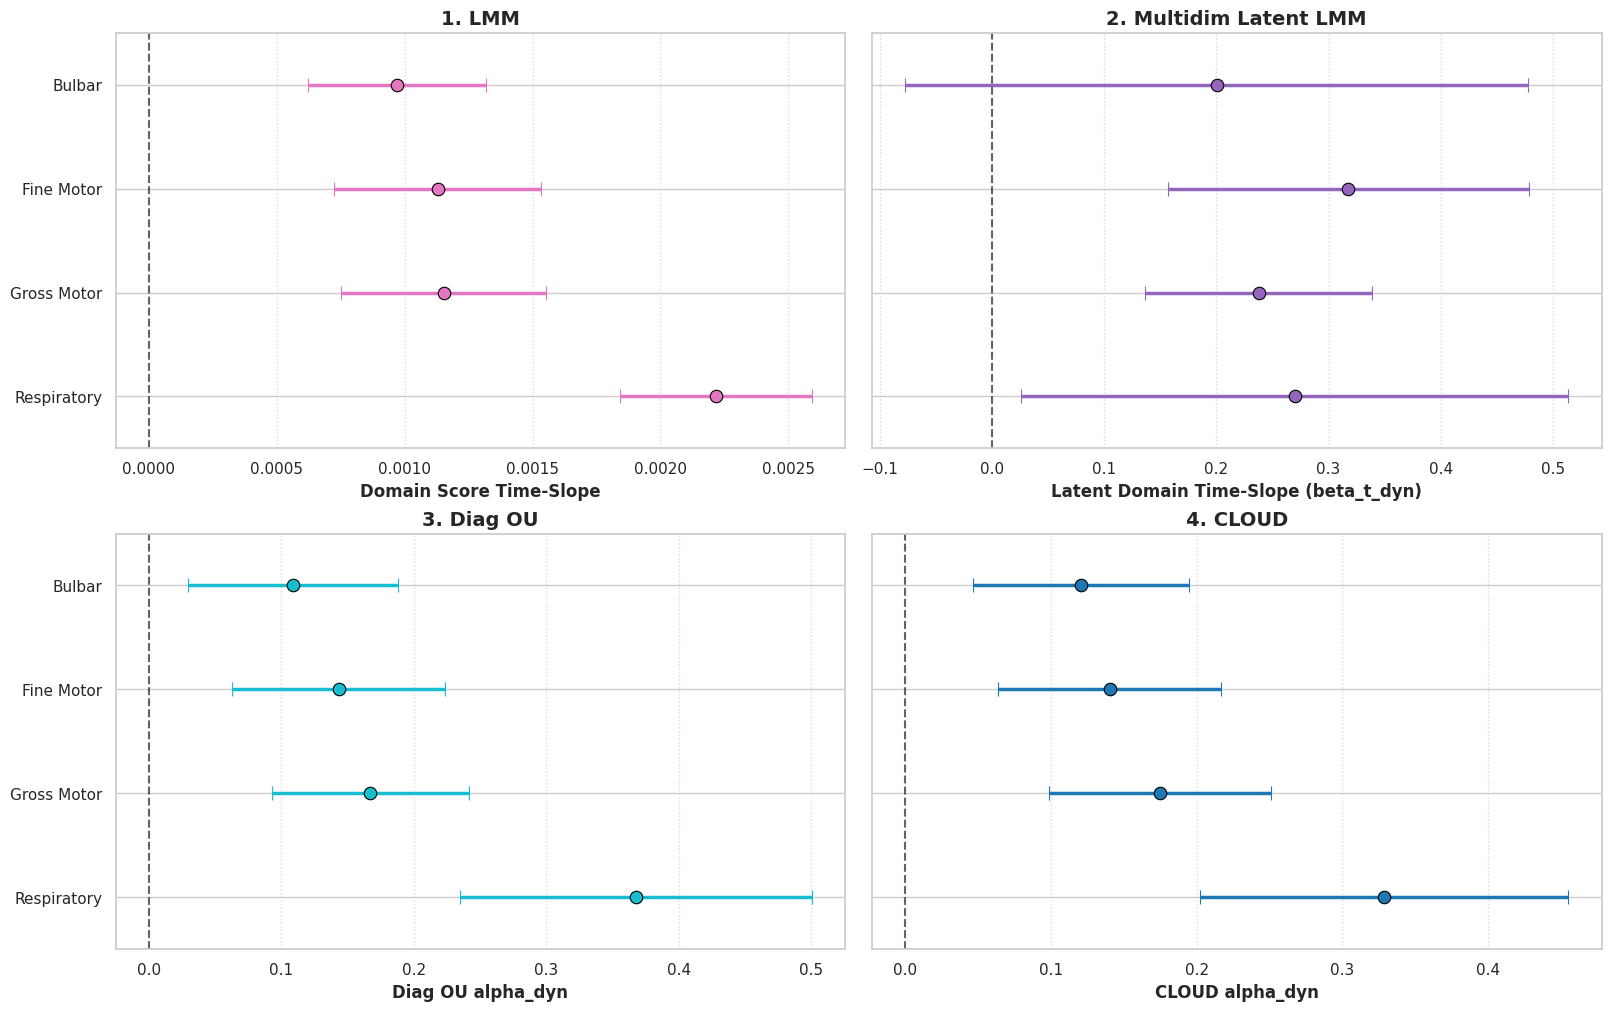

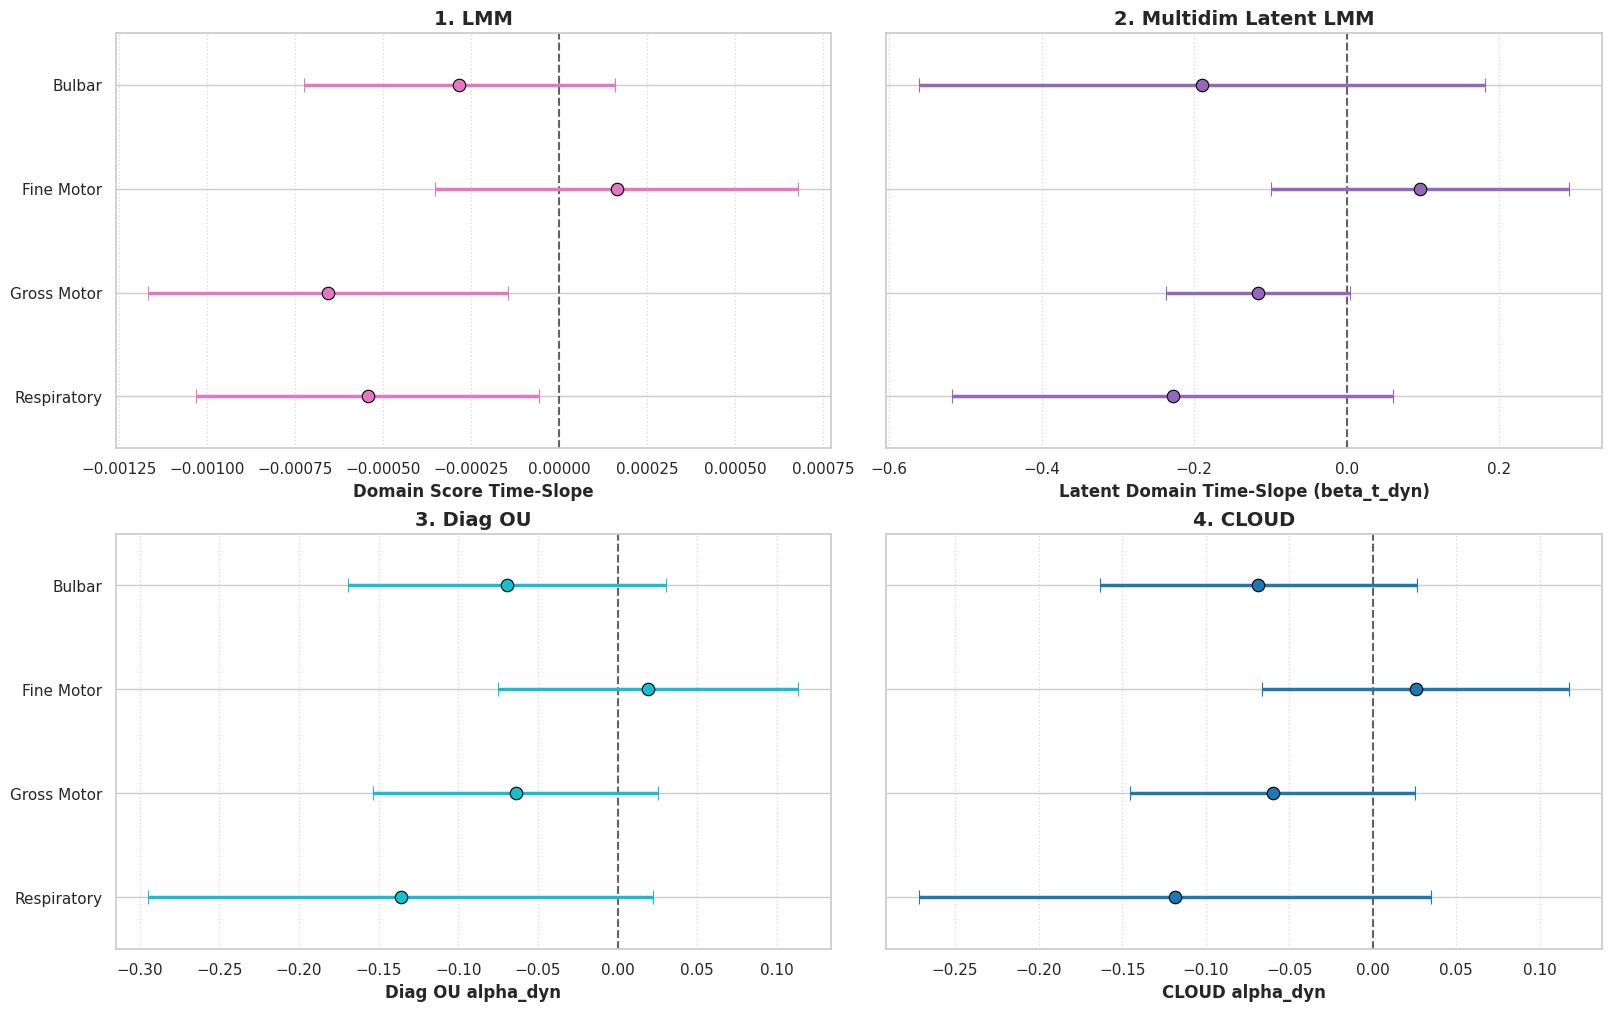

In [5]:
# ==========================================
# Plot D: Domain-Level Forest Plots
# Point Estimate + 95% CI
# 2x2 Layout
#
# IMPORTANT:
# This plot uses direct DOMAIN-LEVEL effects only.
#
# - Model 1 LMM:
#     refits direct domain-score LMMs.
#
# - Model 2 Multidim Latent LMM:
#     uses beta_t_dyn[domain, covariate] directly from the mltlmm Stan summary.
#     Sex/Treatment/Age are intentionally blank because they are measurement-level.
#
# - Model 3 Diag OU:
#     uses alpha_dyn[domain, covariate] directly from the Diag OU Stan summary.
#     Sex/Treatment/Age are intentionally blank because they are measurement-level.
#
# - Model 4 CLOUD:
#     uses alpha_dyn[domain, covariate] directly from the CLOUD Stan summary.
#     Sex/Treatment/Age are intentionally blank because they are measurement-level.
#
# No item-level aggregation is used.
# ==========================================

import glob
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# Optional fallbacks
if 'MODEL2_NAME' not in globals():
    MODEL2_NAME = '2. Multidim Latent LMM'

if 'mcmc_dfs' not in globals():
    mcmc_dfs = {}

if 'model_colors' not in globals():
    model_colors = {}

if 'meas_covariates' not in globals():
    meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
if 'dyn_covariates' not in globals():
    dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
if 'all_covariates' not in globals():
    all_covariates = meas_covariates + dyn_covariates

if 'meas_str' not in globals():
    meas_str = " + ".join(meas_covariates)

if 'dyn_time_str' not in globals():
    dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])


# ==========================================
# Model names and display settings
# ==========================================

diag_ou_model_name = '3. Diag OU'
cloud_model_name = '4. CLOUD'

forest_model_order = [
    '1. LMM',
    MODEL2_NAME,
    diag_ou_model_name,
    cloud_model_name
]

domain_order = [
    'Bulbar',
    'Fine_Motor',
    'Gross_Motor',
    'Respiratory'
]

domain_label_map = {
    'Bulbar': 'Bulbar',
    'Fine_Motor': 'Fine Motor',
    'Gross_Motor': 'Gross Motor',
    'Respiratory': 'Respiratory'
}

model_colors.update({
    '1. LMM': '#e377c2',
    MODEL2_NAME: '#9467bd',
    diag_ou_model_name: '#17becf',
    cloud_model_name: '#1f77b4',
})


# ==========================================
# Helper functions
# ==========================================

def safe_num(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def local_get_est(model_fit, term):
    try:
        v = model_fit.params[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def local_get_se(model_fit, term):
    try:
        v = model_fit.bse[term]
        return 0.0 if pd.isna(v) else float(v)
    except Exception:
        return 0.0


def infer_summary_se(row):
    """
    Infer posterior SE from an MCMC summary row.
    Supports common column names and 95% interval approximation.
    """
    for col in ['sd', 'SD', 'StdDev', 'Std.Dev.', 'Std_Error', 'Std.Error', 'SE']:
        if col in row.index and pd.notna(row[col]):
            return safe_num(row[col])

    if (
        '97.5%' in row.index
        and '2.5%' in row.index
        and pd.notna(row['97.5%'])
        and pd.notna(row['2.5%'])
    ):
        return safe_num((row['97.5%'] - row['2.5%']) / (2 * 1.96))

    if (
        '97.5' in row.index
        and '2.5' in row.index
        and pd.notna(row['97.5'])
        and pd.notna(row['2.5'])
    ):
        return safe_num((row['97.5'] - row['2.5']) / (2 * 1.96))

    return np.nan


def add_domain_cov_row(rows, model, domain, covariate, est, se, source):
    est = safe_num(est)
    se = safe_num(se)

    if not np.isfinite(est):
        return

    z = est / se if np.isfinite(se) and se != 0 else 0.0

    rows.append({
        'Model': model,
        'Domain': domain,
        'Covariate': covariate,
        'Est': est,
        'SE': se,
        'Z_Score': z,
        'Source': source
    })


def get_forest_xlabel(model, cov):
    """
    Axis labels reflect the scale of the direct domain-level quantity.
    """
    if cov in meas_covariates:
        if model == '1. LMM':
            return "Domain Score Difference"
        else:
            return "No Direct Domain-Level Effect"

    else:
        if model == '1. LMM':
            return "Domain Score Time-Slope"
        elif model == MODEL2_NAME:
            return "Latent Domain Time-Slope (beta_t_dyn)"
        elif model == diag_ou_model_name:
            return "Diag OU alpha_dyn"
        elif model == cloud_model_name:
            return "CLOUD alpha_dyn"
        else:
            return "Estimate"


def alias_existing_mcmc_key(model_label):
    """
    If mcmc_dfs contains a likely matching model under another label,
    alias it to the plotting label.
    """
    if model_label in mcmc_dfs and mcmc_dfs[model_label] is not None and not mcmc_dfs[model_label].empty:
        return True

    model_core = model_label.split('.', 1)[-1].strip().lower()

    for key in list(mcmc_dfs.keys()):
        key_core = str(key).split('.', 1)[-1].strip().lower()

        if model_core == key_core:
            mcmc_dfs[model_label] = mcmc_dfs[key]
            print(f" -> Aliased MCMC summary '{key}' to '{model_label}'.")
            return True

        if 'diag' in model_core and 'diag' in key_core:
            mcmc_dfs[model_label] = mcmc_dfs[key]
            print(f" -> Aliased MCMC summary '{key}' to '{model_label}'.")
            return True

        if 'cloud' in model_core and 'cloud' in key_core:
            mcmc_dfs[model_label] = mcmc_dfs[key]
            print(f" -> Aliased MCMC summary '{key}' to '{model_label}'.")
            return True
            
        if 'latent' in model_core and 'mltlmm' in key_core:
            mcmc_dfs[model_label] = mcmc_dfs[key]
            print(f" -> Aliased MCMC summary '{key}' to '{model_label}'.")
            return True

    return False


def auto_load_mcmc_summary(model_label):
    """
    Attempts to load the MCMC summary CSV if it is not already in mcmc_dfs.
    """
    if alias_existing_mcmc_key(model_label):
        return True

    if model_label in mcmc_dfs and mcmc_dfs[model_label] is not None and not mcmc_dfs[model_label].empty:
        return True

    candidate_patterns = []
    if 'diag' in model_label.lower():
        candidate_patterns = [
            "../new_results/*diag*ou*.csv",
            "../new_results/*diag*.csv",
            "./*diag*ou*.csv",
            "./*diag*.csv",
        ]
    elif 'cloud' in model_label.lower():
        candidate_patterns = [
            "../new_results/*cloud*.csv",
            "../new_results/*dahlou*.csv",
            "./*cloud*.csv",
            "./*dahlou*.csv",
        ]
    elif 'latent' in model_label.lower() or 'mltlmm' in model_label.lower():
        candidate_patterns = [
            "../new_results/*mltlmm*.csv",
            "./*mltlmm*.csv",
        ]

    candidate_files = []

    for pat in candidate_patterns:
        candidate_files.extend(glob.glob(pat))

    candidate_files = sorted(list(dict.fromkeys(candidate_files)))

    for path in candidate_files:
        try:
            tmp = pd.read_csv(path)

            if (
                'Parameter' in tmp.columns
                and 'Estimate' in tmp.columns
            ):
                mcmc_dfs[model_label] = tmp
                print(f" -> Auto-loaded MCMC summary for {model_label}: {path}")
                return True

        except Exception:
            pass

    print(
        f" -> No MCMC summary found for {model_label}. "
        f"Direct domain effects for this model will be blank."
    )

    return False


def extract_stan_domain_effects(model_label, rows, param_name='alpha_dyn'):
    """
    Extracts direct domain-level dynamic covariate effects from Stan summaries.
    
    Dynamically targets parameter matrix (e.g. `alpha_dyn` or `beta_t_dyn`).
    Indices mapped as [Domain_idx, Cov_idx].
    """
    loaded = auto_load_mcmc_summary(model_label)

    if not loaded:
        print(f" -> Failed to load MCMC summary to extract {param_name} for {model_label}.")
        return

    df_m = mcmc_dfs[model_label].copy()

    if df_m.empty or 'Parameter' not in df_m.columns or 'Estimate' not in df_m.columns:
        print(f" -> Invalid MCMC summary for {model_label}.")
        return

    # Filter parameter by specified param_name
    alpha_rows = df_m[
        df_m['Parameter'].astype(str).str.contains(rf'^{param_name}\[', regex=True)
    ].copy()

    if alpha_rows.empty:
        print(f" -> No {param_name} parameters found for {model_label}.")
        available = (
            df_m['Parameter']
            .astype(str)
            .str.replace(r'\[.*$', '', regex=True)
            .dropna()
            .unique()
        )
        print(f"    Available parameter families include: {sorted(list(available))[:40]}")
        return

    try:
        alpha_rows[['Domain_idx', 'Cov_idx']] = (
            alpha_rows['Parameter']
            .astype(str)
            .str.extract(r'\[(\d+),(\d+)\]')
            .astype(int)
        )
    except Exception as e:
        print(f" -> Could not parse {param_name} indices for {model_label}: {e}")
        return

    cov_map_dyn = {
        idx + 1: cov
        for idx, cov in enumerate(dyn_covariates)
    }

    n_added = 0

    for _, row in alpha_rows.iterrows():
        dom_idx = int(row['Domain_idx']) - 1
        cov_idx = int(row['Cov_idx'])

        if dom_idx < 0 or dom_idx >= len(domain_order):
            continue

        if cov_idx not in cov_map_dyn:
            continue

        dom = domain_order[dom_idx]
        cov = cov_map_dyn[cov_idx]

        add_domain_cov_row(
            rows,
            model=model_label,
            domain=dom,
            covariate=cov,
            est=row['Estimate'],
            se=infer_summary_se(row),
            source=f'direct_{model_label}_{param_name}'
        )

        n_added += 1

    print(f" -> Extracted {n_added} direct {param_name} domain effects for {model_label}.")


def save_multiformat(filename):
    """Placeholder to handle saving figures in desired formats."""
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    # plt.savefig(f"{filename}.pdf", bbox_inches='tight')


# ==========================================
# Build domain-level covariate-effect table
# ==========================================

domain_cov_rows = []


# --------------------------------------------------
# A. Model 1: Direct domain-level LMM effects
# --------------------------------------------------
# These are truly domain-score effects because the model is refit using
# Bulbar, Fine_Motor, Gross_Motor, or Respiratory as the outcome.

if 'df' in globals():
    for dom in domain_order:
        req_cols = (
            [dom, 'ALSFRS_Delta', 'subject_id']
            + meas_covariates
            + [f"{c}_x_Time" for c in dyn_covariates]
        )

        df_dom_lmm = df.dropna(subset=req_cols).copy()

        if df_dom_lmm.empty:
            print(f" -> No rows available for direct domain LMM: {dom}")
            continue

        dom_formula = f"{dom} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
        dom_fit = None

        try:
            dom_fit = smf.mixedlm(
                dom_formula,
                data=df_dom_lmm,
                groups=df_dom_lmm["subject_id"]
            ).fit(reml=False, disp=False)
        except Exception:
            try:
                dom_fit = smf.ols(dom_formula, data=df_dom_lmm).fit()
            except Exception:
                dom_fit = None

        if dom_fit is None:
            print(f" -> Domain LMM failed for {dom}.")
            continue

        for cov in dyn_covariates:
            term = f"{cov}_x_Time"

            add_domain_cov_row(
                domain_cov_rows,
                model='1. LMM',
                domain=dom,
                covariate=cov,
                est=local_get_est(dom_fit, term),
                se=local_get_se(dom_fit, term),
                source='direct_domain_lmm'
            )


# --------------------------------------------------
# B. Model 2: Multidimensional latent LMM dynamic effects
# --------------------------------------------------
# Pulls beta_t_dyn from the mltlmm Stan summary, which handles 
# the domain-specific time * covariate interactions.

extract_stan_domain_effects(
    model_label=MODEL2_NAME,
    rows=domain_cov_rows,
    param_name='beta_t_dyn'
)


# --------------------------------------------------
# C. Model 3: Diag OU direct alpha_dyn effects
# --------------------------------------------------

extract_stan_domain_effects(
    model_label=diag_ou_model_name,
    rows=domain_cov_rows,
    param_name='alpha_dyn'
)


# --------------------------------------------------
# D. Model 4: CLOUD direct alpha_dyn effects
# --------------------------------------------------

extract_stan_domain_effects(
    model_label=cloud_model_name,
    rows=domain_cov_rows,
    param_name='alpha_dyn'
)


# --------------------------------------------------
# E. Final plotting table
# --------------------------------------------------

df_domain_covs_plot = pd.DataFrame(domain_cov_rows)

if df_domain_covs_plot.empty:
    print(" -> No direct domain-level covariate effects available. Skipping Plot D.")
else:
    df_domain_covs_plot['Model'] = df_domain_covs_plot['Model'].astype(str)

    df_domain_covs_plot['Domain'] = pd.Categorical(
        df_domain_covs_plot['Domain'],
        categories=domain_order,
        ordered=True
    )

    df_domain_covs_plot['Domain_Label'] = (
        df_domain_covs_plot['Domain']
        .astype(str)
        .replace(domain_label_map)
    )

    df_domain_covs_plot['Domain_Label'] = pd.Categorical(
        df_domain_covs_plot['Domain_Label'],
        categories=[domain_label_map[d] for d in domain_order],
        ordered=True
    )

    df_domain_covs_plot['Model'] = pd.Categorical(
        df_domain_covs_plot['Model'],
        categories=forest_model_order,
        ordered=True
    )

    df_domain_covs_plot = df_domain_covs_plot.sort_values(
        ['Covariate', 'Model', 'Domain']
    )

    df_domain_covs_plot.to_csv(
        "domain_level_covariate_effects_for_forest.csv",
        index=False
    )

    print(" -> Saved direct domain-level forest plotting table:")
    print("    domain_level_covariate_effects_for_forest.csv")


# ==========================================
# Generate one domain-level forest plot per covariate
# ==========================================

if not df_domain_covs_plot.empty:
    sns.set_theme(
        style="whitegrid",
        rc={
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white"
        }
    )

    domain_labels = [domain_label_map[d] for d in domain_order]

    # Put Bulbar visually at the top
    domain_to_y = {
        label: len(domain_labels) - 1 - i
        for i, label in enumerate(domain_labels)
    }

    ytick_positions = [domain_to_y[label] for label in domain_labels]
    ytick_labels = domain_labels

    for cov in all_covariates:
        subset = df_domain_covs_plot[
            df_domain_covs_plot['Covariate'].astype(str) == cov
        ].copy()

        if subset.empty:
            print(f" -> No direct domain-level covariate rows found for {cov}. Skipping forest plot.")
            continue

        subset['Model_Str'] = subset['Model'].astype(str)
        subset['Domain_Label_Str'] = subset['Domain_Label'].astype(str)
        subset['Est'] = pd.to_numeric(subset['Est'], errors='coerce')
        subset['SE'] = pd.to_numeric(subset['SE'], errors='coerce')

        subset = subset[subset['Model_Str'].isin(forest_model_order)].copy()

        fig, axes = plt.subplots(
            2, 2,
            figsize=(16, 10),
            sharey=True,
            constrained_layout=True
        )

        axes_flat = axes.flatten()

        for i, model in enumerate(forest_model_order):
            ax = axes_flat[i]

            mod_data = subset[subset['Model_Str'] == model].copy()
            mod_data['y_pos'] = mod_data['Domain_Label_Str'].map(domain_to_y)

            mod_data = mod_data.dropna(subset=['y_pos', 'Est']).copy()
            mod_data['y_pos'] = mod_data['y_pos'].astype(float)
            mod_data['CI_Margin'] = 1.96 * mod_data['SE'].abs()

            mod_data = mod_data.sort_values('y_pos')

            # Zero reference line
            ax.axvline(
                x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1
            )

            if not mod_data.empty:
                c_val = model_colors.get(model, '#333333')

                # Plot rows with valid SE using 95% CI
                with_ci = mod_data[
                    mod_data['CI_Margin'].notna() & np.isfinite(mod_data['CI_Margin'])
                ]

                if not with_ci.empty:
                    ax.errorbar(
                        x=with_ci['Est'].values,
                        y=with_ci['y_pos'].values,
                        xerr=with_ci['CI_Margin'].values,
                        fmt='o', color=c_val, ecolor=c_val, elinewidth=2.5,
                        capsize=5, capthick=2, markersize=9,
                        markeredgecolor='black', markeredgewidth=0.8, zorder=3
                    )

                # Plot rows without valid SE as point-only estimates
                no_ci = mod_data[
                    mod_data['CI_Margin'].isna() | ~np.isfinite(mod_data['CI_Margin'])
                ]

                if not no_ci.empty:
                    ax.scatter(
                        no_ci['Est'].values, no_ci['y_pos'].values,
                        s=90, color=c_val, edgecolor='black',
                        linewidth=0.8, zorder=3
                    )

            else:
                ax.text(
                    0.5, 0.5, "No direct\ndomain-level\nestimate",
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=12, color='gray', fontweight='bold'
                )

            ax.set_title(model, fontweight='bold', fontsize=14)
            ax.set_xlabel(get_forest_xlabel(model, cov), fontweight='bold', fontsize=12)

            ax.grid(True, axis='x', linestyle=':', alpha=0.7, zorder=0)
            ax.set_axisbelow(True)
            ax.set_yticks(ytick_positions)

            if i % 2 == 0:
                ax.set_yticklabels(ytick_labels, fontsize=11)
            else:
                ax.tick_params(axis='y', labelleft=False)

            ax.set_ylim(-0.5, len(domain_labels) - 0.5)

        save_multiformat(f"Fig_D_Domain_Forest_{cov}")

        print(f" -> Generated domain-level forest plot for {cov}.")